# model/03: Loss Functions

This notebook explains the loss functions used to train the neural SDE surrogate.

**Contents:**
1. GaussianTransitionNLL — per-step negative log-likelihood under the Euler-Maruyama Gaussian assumption
2. Teacher Forcing — why it works and how it avoids error compounding
3. MeanMatchingLoss and VarianceMatchingLoss — moment-matching losses for rollout validation
4. CombinedTrajectoryLoss — weighted combination
5. Internal Species Masking — excluding external species from the loss

In [3]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

from _shared.plotting import setup_style

setup_style()

import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

## 1. GaussianTransitionNLL

The Euler-Maruyama discretization of the SDE
$$dX = f_\theta(X, t, c)\,dt + g_\theta(X, t, c)\,dW$$
implies a Gaussian transition distribution at each step:
$$X_{t+dt} \mid X_t \sim \mathcal{N}\!\left(X_t + f_\theta \cdot dt,\; g_\theta^2 \cdot dt \cdot I\right)$$

The per-step negative log-likelihood is:
$$\mathcal{L}_{\text{NLL}} = \frac{1}{2}\sum_s \left[\log(2\pi \sigma_s^2) + \frac{(y_{t+1,s} - \mu_s)^2}{\sigma_s^2}\right]$$
where $\mu_s = x_s + f_{\theta,s} \cdot dt$ and $\sigma_s^2 = g_{\theta,s}^2 \cdot dt$.

This loss jointly trains the drift (mean prediction) and diffusion (variance prediction) from a single principled objective.

In [4]:
from crn_surrogate.training.losses import GaussianTransitionNLL

from crn_surrogate.data.generation.reference_crns import birth_death
from crn_surrogate.encoder.tensor_repr import crn_to_tensor_repr
from crn_surrogate.configs.model_config import EncoderConfig, SDEConfig
from crn_surrogate.encoder.bipartite_gnn import BipartiteGNNEncoder
from crn_surrogate.simulator.neural_sde import CRNNeuralSDE
from crn_surrogate.simulation import GillespieSSA, interpolate_to_grid

# Setup: birth-death CRN with untrained neural SDE
crn = birth_death(k_birth=2.0, k_death=0.5)
crn_repr = crn_to_tensor_repr(crn)

enc_cfg = EncoderConfig(d_model=32, n_layers=2)
sde_cfg = SDEConfig.from_crn(crn, d_model=32, d_hidden=64, clip_state=True)

encoder = BipartiteGNNEncoder(enc_cfg)
sde = CRNNeuralSDE(sde_cfg, n_species=1)

loss_fn = GaussianTransitionNLL()

# Generate a small batch of SSA trajectories
ssa = GillespieSSA()
T_MAX, N_GRID, M = 15.0, 40, 8
time_grid = torch.linspace(0.0, T_MAX, N_GRID)
init_state = torch.tensor([0.0])

trajs_list = []
for _ in range(M):
    traj = ssa.simulate(
        stoichiometry=crn.stoichiometry_matrix,
        propensity_fn=crn.evaluate_propensities,
        initial_state=init_state.clone(),
        t_max=T_MAX,
    )
    trajs_list.append(interpolate_to_grid(traj.times, traj.states, time_grid))
trajs = torch.stack(trajs_list)  # (M, T, n_species)

print(f"SSA trajectories: {trajs.shape}  (M, T, n_species)")

# Compute the batched NLL using teacher forcing.
# GaussianTransitionNLL.compute() handles all M*(T-1) transitions in one forward pass.
crn_ctx = encoder(crn_repr, init_state)
dt = T_MAX / (N_GRID - 1)

with torch.no_grad():
    nll = loss_fn.compute(sde, crn_ctx, trajs, time_grid, dt=dt)

print(f"\nMean per-step NLL (untrained): {nll.item():.4f}")
print("(Will decrease after training as drift and diffusion improve)")

SSA trajectories: torch.Size([8, 40, 1])  (M, T, n_species)

Mean per-step NLL (untrained): 1.6455
(Will decrease after training as drift and diffusion improve)


## 2. Teacher Forcing

**Teacher forcing** means that at each training step, we feed the model the *true* previous state from the SSA trajectory rather than the model's own prediction.

**Why it works:**
- Every training step operates on states drawn from the real trajectory distribution
- Gradients are clean and informative at every step
- The NLL objective naturally penalizes both mean error (incorrect drift) and variance error (incorrect diffusion)

**Contrast with full rollout:**
- Full rollout generates states by running the model forward from the initial condition
- By step T, the model operates on states that may differ significantly from the training distribution
- Early errors compound, producing noisy gradients at later steps
- Computationally expensive: K rollouts × T steps of SDE integration per training item

Teacher forcing is the recommended primary training objective. Full rollout can be used for validation and optional fine-tuning.

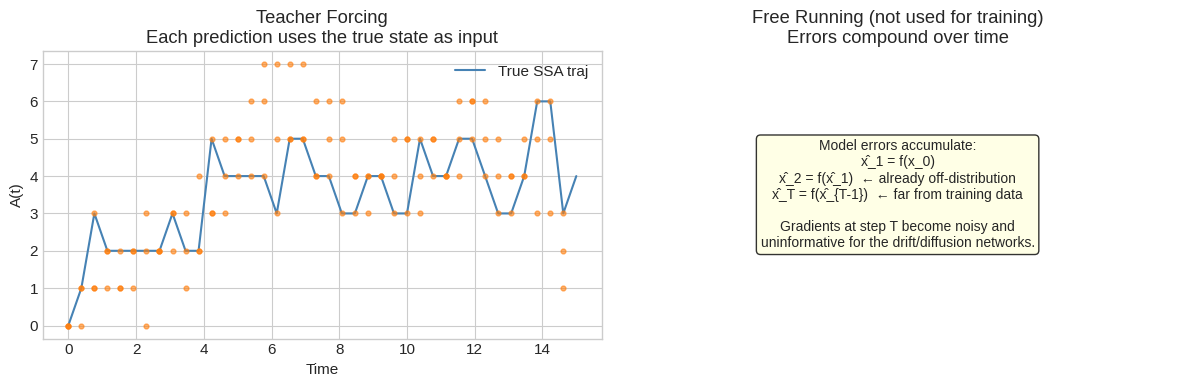

In [5]:
# Visualize the difference between teacher forcing and free-running inference
t = time_grid.numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Teacher forcing: always uses true state from SSA
axes[0].plot(t, trajs[0, :, 0].numpy(), color="steelblue", lw=1.5, label="True SSA traj")
for m in range(3):
    axes[0].scatter(t[:-1], trajs[m, :-1, 0].numpy(), s=12, color="tab:orange",
                    alpha=0.6, zorder=5)
axes[0].set_title("Teacher Forcing\nEach prediction uses the true state as input")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("A(t)")
axes[0].legend()

# Free running: uses model's own output (would compound errors)
axes[1].set_title("Free Running (not used for training)\nErrors compound over time")
axes[1].text(0.5, 0.5,
             "Model errors accumulate:\n"
             "x̂_1 = f(x_0)\n"
             "x̂_2 = f(x̂_1)  ← already off-distribution\n"
             "x̂_T = f(x̂_{T-1})  ← far from training data\n\n"
             "Gradients at step T become noisy and\n"
             "uninformative for the drift/diffusion networks.",
             transform=axes[1].transAxes, ha="center", va="center",
             fontsize=10, bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 3. MeanMatchingLoss and VarianceMatchingLoss

These moment-matching losses are useful for **rollout validation**: comparing the statistics of the model's generated trajectories against the SSA ground truth.

- `MeanMatchingLoss`: MSE between the empirical mean trajectories $\hat{\mu}(t)$ and $\mu_{\text{SSA}}(t)$
- `VarianceMatchingLoss`: MSE between the empirical variance trajectories $\hat{\sigma}^2(t)$ and $\sigma^2_{\text{SSA}}(t)$

Both require M ≥ 2 trajectories to compute empirical statistics. If M = 1, both raise `ValueError` — there is no silent fallback that returns zero.

In [6]:
from crn_surrogate.training.losses import MeanMatchingLoss, VarianceMatchingLoss

mean_loss_fn = MeanMatchingLoss()
var_loss_fn  = VarianceMatchingLoss()

# Generate two sets of M trajectories: "predicted" vs ground truth
M_eval = 20

def _run_ensemble(m: int) -> torch.Tensor:
    trajs = []
    for _ in range(m):
        traj = ssa.simulate(
            stoichiometry=crn.stoichiometry_matrix,
            propensity_fn=crn.evaluate_propensities,
            initial_state=init_state.clone(),
            t_max=T_MAX,
        )
        trajs.append(interpolate_to_grid(traj.times, traj.states, time_grid))
    return torch.stack(trajs)  # (M, T, n_species)

trajs_pred = _run_ensemble(M_eval)
trajs_gt   = _run_ensemble(M_eval)

mean_loss = mean_loss_fn.compute(trajs_pred, trajs_gt).item()
var_loss  = var_loss_fn.compute(trajs_pred, trajs_gt).item()

print(f"MeanMatchingLoss (pred vs gt SSA):  {mean_loss:.4f}")
print(f"VarianceMatchingLoss (pred vs gt):  {var_loss:.4f}")
print()
print("Both losses should be small when comparing two SSA batches from the same CRN.")
print("They will be large when comparing an untrained neural SDE against SSA.")

# Verify that M=1 raises an error
try:
    var_loss_fn.compute(trajs_pred[:1], trajs_gt[:1])
    print("ERROR: expected ValueError for M=1")
except ValueError as e:
    print(f"\nCorrectly raises ValueError for M=1: {e}")

MeanMatchingLoss (pred vs gt SSA):  0.7036
VarianceMatchingLoss (pred vs gt):  0.5466

Both losses should be small when comparing two SSA batches from the same CRN.
They will be large when comparing an untrained neural SDE against SSA.

Correctly raises ValueError for M=1: VarianceMatchingLoss requires K >= 2 SDE samples, got K=1


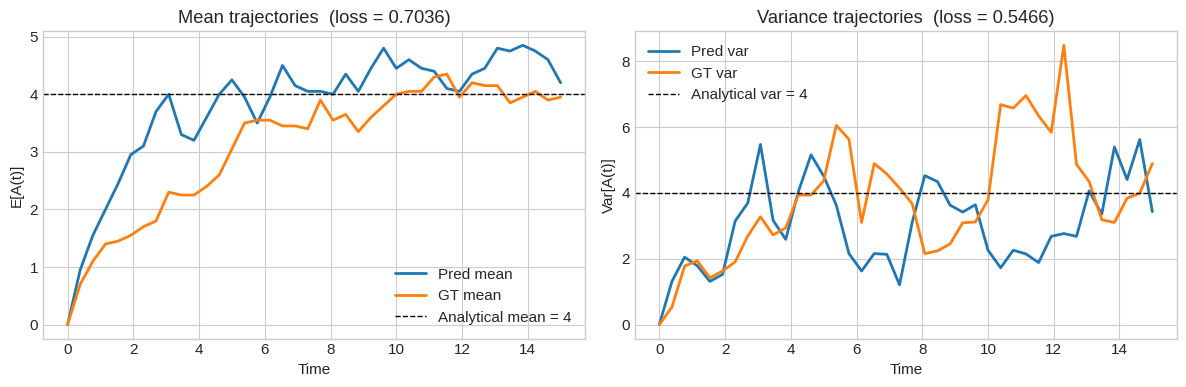

In [7]:
# Visualize mean and variance trajectories
t = time_grid.numpy()
mean_pred = trajs_pred[:, :, 0].mean(dim=0).numpy()
mean_gt   = trajs_gt[:, :, 0].mean(dim=0).numpy()
var_pred  = trajs_pred[:, :, 0].var(dim=0).numpy()
var_gt    = trajs_gt[:, :, 0].var(dim=0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t, mean_pred, lw=2, color="tab:blue", label="Pred mean")
axes[0].plot(t, mean_gt,   lw=2, color="tab:orange", label="GT mean")
axes[0].axhline(4.0, color="black", linestyle="--", lw=1, label="Analytical mean = 4")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("E[A(t)]")
axes[0].set_title(f"Mean trajectories  (loss = {mean_loss:.4f})")
axes[0].legend()

axes[1].plot(t, var_pred, lw=2, color="tab:blue", label="Pred var")
axes[1].plot(t, var_gt,   lw=2, color="tab:orange", label="GT var")
axes[1].axhline(4.0, color="black", linestyle="--", lw=1, label="Analytical var = 4")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Var[A(t)]")
axes[1].set_title(f"Variance trajectories  (loss = {var_loss:.4f})")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. CombinedTrajectoryLoss

`CombinedTrajectoryLoss` is a weighted sum of mean and variance matching losses:
$$\mathcal{L}_{\text{combined}} = \mathcal{L}_{\text{mean}} + w_{\text{var}} \cdot \mathcal{L}_{\text{var}}$$

This is the full-rollout alternative to the NLL teacher forcing loss. It requires running K SDE rollouts per training item, making it significantly more expensive per epoch (see the loss comparison experiment).

In [8]:
from crn_surrogate.training.losses import CombinedTrajectoryLoss

combined_fn = CombinedTrajectoryLoss(var_weight=0.5)
combined_loss = combined_fn.compute(trajs_pred, trajs_gt).item()

print(f"CombinedTrajectoryLoss (var_weight=0.5): {combined_loss:.4f}")
print(f"  = MeanMatchingLoss + 0.5 * VarianceMatchingLoss")
print(f"  = {mean_loss:.4f} + 0.5 * {var_loss:.4f} = {mean_loss + 0.5 * var_loss:.4f}")

CombinedTrajectoryLoss (var_weight=0.5): 0.9769
  = MeanMatchingLoss + 0.5 * VarianceMatchingLoss
  = 0.7036 + 0.5 * 0.5466 = 0.9769


## 5. Internal Species Masking

When external species are present, the loss should only evaluate the model's prediction quality on **internal** species. External species are fully prescribed by the input protocol — there is nothing for the model to learn about them.

The species mask (from `CRNTrajectoryDataset`) marks external species as `False`. The loss function applies this mask to exclude external species from all loss computations.

In [9]:
from crn_surrogate.crn.crn import CRN
from crn_surrogate.crn.reaction import Reaction
from crn_surrogate.crn.propensities import hill, mass_action as mass_act

# CRN with 2 species: A (internal) and I (external)
crn_ext = CRN(
    reactions=[
        Reaction(
            stoichiometry=torch.tensor([1, 0]),
            propensity=hill(v_max=5.0, k_m=10.0, hill_coefficient=2.0, species_index=1),
        ),
        Reaction(
            stoichiometry=torch.tensor([-1, 0]),
            propensity=mass_act(0.2, torch.tensor([1.0, 0.0])),
        ),
    ],
    species_names=["A", "I"],
    external_species=frozenset({1}),
)
print(f"CRN: {crn_ext}")
print(f"is_external: {crn_ext.is_external}")

# Synthetic trajectories for 2 species, shape (M, T, 2)
M_demo, T_demo = 10, 30
x_pred = torch.randn(M_demo, T_demo, 2) * 2 + 5  # random predictions
x_true = torch.randn(M_demo, T_demo, 2) * 2 + 5  # random ground truth

# Mask: True for internal species, False for external
species_mask = torch.tensor([True, False])  # A=True, I=False

mean_fn = MeanMatchingLoss()
var_fn  = VarianceMatchingLoss()

loss_with_mask    = mean_fn.compute(x_pred, x_true, mask=species_mask).item()
loss_without_mask = mean_fn.compute(x_pred, x_true, mask=None).item()

print(f"\nMeanMatchingLoss with mask (A only):    {loss_with_mask:.4f}")
print(f"MeanMatchingLoss without mask (A + I):  {loss_without_mask:.4f}")
print(f"\nIncluding the external species in the loss would add spurious signal:\nthe model is evaluated on I even though I is fully determined by the protocol.")

CRN: CRN(n_species=2, n_reactions=2, species=('A', 'I'))
is_external: [False  True]

MeanMatchingLoss with mask (A only):    0.9852
MeanMatchingLoss without mask (A + I):  1.0970

Including the external species in the loss would add spurious signal:
the model is evaluated on I even though I is fully determined by the protocol.


## Summary

| Loss | Training mode | Cost | Use case |
|------|--------------|------|----------|
| `GaussianTransitionNLL` | Teacher forcing | Cheap (no rollout) | Primary training objective |
| `MeanMatchingLoss` | Full rollout | Expensive (K rollouts) | Rollout validation |
| `VarianceMatchingLoss` | Full rollout | Expensive (K rollouts) | Rollout validation |
| `CombinedTrajectoryLoss` | Full rollout | Expensive (K rollouts) | Optional fine-tuning |

**Key points:**
- Teacher forcing (NLL) keeps every step on-distribution and is 10-16x faster than full rollout
- NLL jointly trains drift and variance from one principled objective with no loss-weight hyperparameter
- Species masking must exclude external species from all loss computations
- `VarianceMatchingLoss` requires M ≥ 2 trajectories and raises `ValueError` for M = 1